# Pre-Processing Dataset

In [ ]:
#Intalling Utide tidal analyis libary
!pip install utide
!pip install ipdb

In [ ]:
#Importing relevant libaries
import ipdb
import matplotlib.pyplot as plt
import utide
import numpy as np
import pandas as pd
import seaborn as sns
import glob
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import random

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [ ]:
#Importing datsets
#PATH_DATA = '/content/drive/MyDrive/CI513/Coursework/Data'
df_FILE_BTN_WEATHER = pd.read_csv('22829503-1.csv')
df_FILE_SFD_WAVE = pd.read_csv('22829503-2.csv')
df_FILE_BTN_TIDE = pd.read_csv('22829503-3.csv')
random_seed = 600

random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

In [ ]:
df_FILE_BTN_WEATHER

,Date/Time (GMT),Wind (m/s),Wind Dir (deg),Gust (m/s),Baro (hPa),Tair (degC),Rainfall (mm),Solar (W/m^2),UV (W/m^2),RH (%),flag
0,01/01/2018 00:00,9.2,255,12.1,999,8.0,0,9999,9999,74,0
1,01/01/2018 00:10,9.0,259,11.9,998,7.9,0,9999,9999,72,0
2,01/01/2018 00:20,9.0,254,12.0,999,7.8,0,9999,9999,72,0
3,01/01/2018 00:30,8.6,250,10.7,999,7.6,0,9999,9999,74,0
4,01/01/2018 00:40,8.6,254,10.4,999,7.4,0,9999,9999,76,0
...,...,...,...,...,...,...,...,...,...,...,...
433723,31/03/2026 23:10,0.4,121,0.4,1026,9.7,0,9999,9999,88,0
433724,31/03/2026 23:20,0.3,341,0.3,1026,9.7,0,9999,9999,89,0
433725,31/03/2026 23:30,0.2,174,0.3,1025,9.5,0,9999,9999,89,0
433726,31/03/2026 23:40,0.9,9,1.1,1025,10.0,0,9999,9999,91,0


In [ ]:
#Dropping unessicary coloumns
columns = ['UV (W/m^2)','Solar (W/m^2)','Rainfall (mm)','RH (%)','Tair (degC)','flag', ]
btn_weather_dropped = df_FILE_BTN_WEATHER.drop(columns= columns)

#Converting string to DateTime object
btn_weather_dropped['Date/Time (GMT)'] = pd.to_datetime(btn_weather_dropped['Date/Time (GMT)'], dayfirst=True)

#Setting the target period
start_time = '2018-01-01 02:00'
end_time = '2026-01-01 00:00'
#Applying the start and end date/time
#using .copy() to ensure final_Btn_Weather is an independent object creating a barrier between the original data so it doesn't get editied
btn_weather_time = btn_weather_dropped[btn_weather_dropped['Date/Time (GMT)'].between(start_time, end_time)].copy()
btn_weather_time

,Date/Time (GMT),Wind (m/s),Wind Dir (deg),Gust (m/s),Baro (hPa)
12,2018-01-01 02:00:00,7.0,258,9.5,1000
13,2018-01-01 02:10:00,5.8,250,7.5,1000
14,2018-01-01 02:20:00,4.7,255,6.5,1000
15,2018-01-01 02:30:00,3.7,263,4.8,1000
16,2018-01-01 02:40:00,4.7,275,6.2,1000
...,...,...,...,...,...
420764,2025-12-31 23:20:00,4.0,275,5.0,1019
420765,2025-12-31 23:30:00,4.9,275,6.0,1019
420766,2025-12-31 23:40:00,4.6,266,5.6,1018
420767,2025-12-31 23:50:00,4.5,278,5.7,1018


In [ ]:
#Replacing 9999 values with nan
btn_weather_time.replace(9999, np.nan, inplace=True)

In [ ]:
#Checking to see how much of the dataset is null values
round((btn_weather_time.isnull().sum() / btn_weather_time.shape[0]) * 100, 2)

Date/Time (GMT)    0.00
Wind (m/s)         0.88
Wind Dir (deg)     0.88
Gust (m/s)         0.88
Baro (hPa)         0.88
dtype: float64

In [ ]:
#List of coloumns with 0.88% null data
cols_to_fix =['Gust (m/s)', 'Baro (hPa)', 'Wind (m/s)', 'Wind Dir (deg)']

#Implementing interpolation on null data
btn_weather_time[cols_to_fix] = btn_weather_time[cols_to_fix].interpolate()

#Filling any remaning null values
btn_weather_time[cols_to_fix] = btn_weather_time[cols_to_fix].bfill().ffill()

In [ ]:
#Checking if null values have been filled
round((btn_weather_time.isnull().sum() / btn_weather_time.shape[0]) * 100, 2)

Date/Time (GMT)    0.0
Wind (m/s)         0.0
Wind Dir (deg)     0.0
Gust (m/s)         0.0
Baro (hPa)         0.0
dtype: float64

In [ ]:
btn_weather_clean = btn_weather_time.copy()

In [ ]:
#Converting deg into radians for NumPy to understand
btn_weather_clean['wind_rad'] = np.radians(btn_weather_clean['Wind Dir (deg)'])

#Mapping the wind direction into a 2D coordinates cos being x and sin becoming y
btn_weather_clean['wind_sin'] = np.sin(btn_weather_clean['wind_rad'])
btn_weather_clean['wind_cos'] = np.cos(btn_weather_clean['wind_rad'])

#Creating a new dataframe containing the sin and cos features
btn_weather_features = btn_weather_clean[['wind_sin', 'wind_cos']]


In [ ]:
btn_weather_features

,wind_sin,wind_cos
12,-0.978148,-0.207912
13,-0.939693,-0.342020
14,-0.965926,-0.258819
15,-0.992546,-0.121869
16,-0.996195,0.087156
...,...,...
420764,-0.996195,0.087156
420765,-0.996195,0.087156
420766,-0.997564,-0.069756
420767,-0.990268,0.139173


In [ ]:
#Dropping rad as its not needed to find where the wind is blowing in the 2D "circle"
columns = ['wind_rad']
btn_weather_dropped = btn_weather_clean.drop(columns= columns)

In [ ]:
btn_weather_baro_norm = btn_weather_dropped[(btn_weather_clean['Baro (hPa)'] >= 950) & (btn_weather_dropped['Baro (hPa)'] <= 1050)]

In [ ]:
btn_weather_final = btn_weather_baro_norm

In [ ]:
btn_weather_final

,Date/Time (GMT),Wind (m/s),Wind Dir (deg),Gust (m/s),Baro (hPa),wind_sin,wind_cos
12,2018-01-01 02:00:00,7.0,258.0,9.5,1000.0,-0.978148,-0.207912
13,2018-01-01 02:10:00,5.8,250.0,7.5,1000.0,-0.939693,-0.342020
14,2018-01-01 02:20:00,4.7,255.0,6.5,1000.0,-0.965926,-0.258819
15,2018-01-01 02:30:00,3.7,263.0,4.8,1000.0,-0.992546,-0.121869
16,2018-01-01 02:40:00,4.7,275.0,6.2,1000.0,-0.996195,0.087156
...,...,...,...,...,...,...,...
420764,2025-12-31 23:20:00,4.0,275.0,5.0,1019.0,-0.996195,0.087156
420765,2025-12-31 23:30:00,4.9,275.0,6.0,1019.0,-0.996195,0.087156
420766,2025-12-31 23:40:00,4.6,266.0,5.6,1018.0,-0.997564,-0.069756
420767,2025-12-31 23:50:00,4.5,278.0,5.7,1018.0,-0.990268,0.139173


In [ ]:
df_FILE_SFD_WAVE

,Date/Time (GMT),Latitude,Longitude,Flag,Hs (Hm0)(m),Hmax (m),Tp (s),Tz (Tm)(s),Dirp (degrees),Spread (deg),SST (deg C)
0,01/01/2014 00:00,50.76664,0.07504,0,2.16,9999.00,7.1,4.9,222,16,9.0
1,01/01/2014 00:30,50.76664,0.07504,0,2.33,3.60,6.7,5.1,219,14,9.1
2,01/01/2014 01:00,50.76664,0.07504,0,2.35,3.61,7.1,5.0,222,16,9.0
3,01/01/2014 01:30,50.76660,0.07497,0,2.32,3.98,7.1,5.3,218,15,9.1
4,01/01/2014 02:00,50.76660,0.07491,0,2.36,3.45,7.1,5.3,215,19,9.1
...,...,...,...,...,...,...,...,...,...,...,...
211867,31/01/2026 21:30,50.76645,0.07620,0,1.05,1.19,15.4,4.3,221,36,8.9
211868,31/01/2026 22:00,50.76677,0.07499,0,1.00,1.43,15.4,4.2,201,43,8.9
211869,31/01/2026 22:30,50.76671,0.07484,0,1.06,1.46,15.4,4.2,243,38,8.9
211870,31/01/2026 23:00,50.76667,0.07487,0,1.03,1.36,16.7,4.2,236,30,8.9


In [ ]:
columns = ['Flag','Latitude','Longitude', 'Spread (deg)','Dirp (degrees)','Tp (s)','SST (deg C)','Hmax (m)']
sfd_wave_dropped = df_FILE_SFD_WAVE.drop(columns= columns)
sfd_wave_dropped['Date/Time (GMT)'] = pd.to_datetime(sfd_wave_dropped['Date/Time (GMT)'], dayfirst=True)

start_time = '2018-01-01 00:00'
end_time = '2026-01-01 00:00'

sfd_wave_time = sfd_wave_dropped[sfd_wave_dropped['Date/Time (GMT)'].between(start_time, end_time)].copy()
sfd_wave_time.head()

,Date/Time (GMT),Hs (Hm0)(m),Tz (Tm)(s)
70128,2018-01-01 00:00:00,2.51,5.6
70129,2018-01-01 00:30:00,2.69,5.7
70130,2018-01-01 01:00:00,2.46,5.4
70131,2018-01-01 01:30:00,2.29,5.5
70132,2018-01-01 02:00:00,2.07,5.3


In [ ]:
sfd_wave_time.replace(9999, np.nan, inplace =True)
sfd_wave_time.head()

,Date/Time (GMT),Hs (Hm0)(m),Tz (Tm)(s)
70128,2018-01-01 00:00:00,2.51,5.6
70129,2018-01-01 00:30:00,2.69,5.7
70130,2018-01-01 01:00:00,2.46,5.4
70131,2018-01-01 01:30:00,2.29,5.5
70132,2018-01-01 02:00:00,2.07,5.3


In [ ]:
round((sfd_wave_time.isnull().sum() / sfd_wave_time.shape[0]) * 100, 2)

Date/Time (GMT)    0.00
Hs (Hm0)(m)        0.82
Tz (Tm)(s)         0.82
dtype: float64

In [ ]:
#Taking missing values and filling them in by "drawing a line" between the last known data point
#and the next known data point limted by 24 hour gaps
sfd_wave_clean = sfd_wave_time.interpolate(method='linear', limit=24)

In [ ]:
#Creating lagged features for time step 1 and 2 (t-1, t-2)
sfd_wave_clean['Hs_t-1'] = sfd_wave_clean['Hs (Hm0)(m)'].shift(1)
sfd_wave_clean['Hs_t-2'] = sfd_wave_clean['Hs (Hm0)(m)'].shift(2)

#Removing rows with NaN values made by shifting the data down
sfd_wave_lags = sfd_wave_clean.dropna()


In [ ]:
sfd_wave_lags.loc[:,['Hs (Hm0)(m)', 'Tz (Tm)(s)']] = sfd_wave_lags[['Hs (Hm0)(m)', 'Tz (Tm)(s)']].ffill().bfill()

In [ ]:
round((sfd_wave_lags.isnull().sum() / sfd_wave_lags.shape[0]) * 100, 2)

Date/Time (GMT)    0.0
Hs (Hm0)(m)        0.0
Tz (Tm)(s)         0.0
Hs_t-1             0.0
Hs_t-2             0.0
dtype: float64

In [ ]:
sfd_wave_final = sfd_wave_lags.copy()

In [ ]:
sfd_wave_final

,Date/Time (GMT),Hs (Hm0)(m),Tz (Tm)(s),Hs_t-1,Hs_t-2
70130,2018-01-01 01:00:00,2.46,5.4,2.69,2.51
70131,2018-01-01 01:30:00,2.29,5.5,2.46,2.69
70132,2018-01-01 02:00:00,2.07,5.3,2.29,2.46
70133,2018-01-01 02:30:00,2.02,5.2,2.07,2.29
70134,2018-01-01 03:00:00,2.00,5.2,2.02,2.07
...,...,...,...,...,...
210380,2025-12-31 22:00:00,0.65,3.1,0.43,0.37
210381,2025-12-31 22:30:00,0.71,3.2,0.65,0.43
210382,2025-12-31 23:00:00,0.74,3.3,0.71,0.65
210383,2025-12-31 23:30:00,0.74,3.3,0.74,0.71


In [ ]:
df_FILE_BTN_TIDE.tail()

,Date/Time (GMT),Tide_OD,Tide_CD,Residual (m),Flag
407659,31/01/2026 23:10,3,6,0,1
407660,31/01/2026 23:20,3,6,0,1
407661,31/01/2026 23:30,2,6,0,1
407662,31/01/2026 23:40,2,6,0,1
407663,31/01/2026 23:50,2,6,0,1


In [ ]:
columns = ['Residual (m)','Flag','Tide_OD']
btn_tide_dropped = df_FILE_BTN_TIDE.drop(columns= columns)
btn_tide_dropped['Date/Time (GMT)'] = pd.to_datetime(btn_tide_dropped['Date/Time (GMT)'], dayfirst=True)

start_time = '2018-01-01 02:00'
end_time = '2026-01-01 00:00'

btn_tide_time = btn_tide_dropped[btn_tide_dropped['Date/Time (GMT)'].between(start_time, end_time)].copy()

btn_tide_time

,Date/Time (GMT),Tide_CD
12,2018-01-01 02:00:00,9999
13,2018-01-01 02:10:00,9999
14,2018-01-01 02:20:00,9999
15,2018-01-01 02:30:00,9999
16,2018-01-01 02:40:00,9999
...,...,...
403196,2025-12-31 23:20:00,4
403197,2025-12-31 23:30:00,4
403198,2025-12-31 23:40:00,3
403199,2025-12-31 23:50:00,3


In [ ]:
btn_tide_time.replace(9999, np.nan, inplace=True)
btn_tide_time

,Date/Time (GMT),Tide_CD
12,2018-01-01 02:00:00,NaN
13,2018-01-01 02:10:00,NaN
14,2018-01-01 02:20:00,NaN
15,2018-01-01 02:30:00,NaN
16,2018-01-01 02:40:00,NaN
...,...,...
403196,2025-12-31 23:20:00,4.0
403197,2025-12-31 23:30:00,4.0
403198,2025-12-31 23:40:00,3.0
403199,2025-12-31 23:50:00,3.0


In [ ]:
round((btn_tide_time.isnull().sum() / btn_tide_time.shape[0]) * 100, 2)

Date/Time (GMT)    0.00
Tide_CD            6.77
dtype: float64

In [ ]:
#Any tides less the 0m or greater than 7m get changed to NaN values
btn_tide_time.loc[(btn_tide_time['Tide_CD'] < 0) | (btn_tide_time['Tide_CD'] > 7), 'Tide_CD'] = np.nan

#Taking observed water-level and breaking it into individual cycles changed by celestial mechanics (The moon and sun)
coef = utide.solve(btn_tide_time.index, btn_tide_time['Tide_CD'].values,
                   lat=50.82,           #Paramount for nodal corrections also the latitude for Brighton
                   nodal=True,          #Nodal corrections for lunar wobble
                   trend=True,          #Captures the Chart Datum offset. The data is measured from the lowest predicted tide not the ocean floor
                   method='ols')        #Ordinary least squares

#Applying the generated tidal patterns
reconstruction = utide.reconstruct(btn_tide_time.index, coef)

#Filling in any missing values
btn_tide_time['tide_filled'] = btn_tide_time['Tide_CD'].fillna(pd.Series(reconstruction.h, index=btn_tide_time.index))
#Rounded to 2dp instead of truncating to integers for higher accuracy
btn_tide_time['tide_filled'] = btn_tide_time['tide_filled'].round(0).astype('Int64')

btn_tide_clean = btn_tide_time.copy()

#Esnuring the filled values are valid with the existing positive heights
print(btn_tide_time[['Tide_CD', 'tide_filled']].describe())

solve: matrix prep ... solution ... done.
prep/calcs ... done.
             Tide_CD  tide_filled
count  372509.000000     403189.0
mean        3.657589     3.683645
std         1.663059      1.60111
min         0.000000          0.0
25%         2.000000          2.0
50%         4.000000          4.0
75%         5.000000          5.0
max         7.000000          7.0


In [ ]:
columns = ['Tide_CD']
btn_tide_final = btn_tide_time.drop(columns= columns)

In [ ]:
btn_tide_final

,Date/Time (GMT),tide_filled
12,2018-01-01 02:00:00,4
13,2018-01-01 02:10:00,4
14,2018-01-01 02:20:00,4
15,2018-01-01 02:30:00,4
16,2018-01-01 02:40:00,4
...,...,...
403196,2025-12-31 23:20:00,4
403197,2025-12-31 23:30:00,4
403198,2025-12-31 23:40:00,3
403199,2025-12-31 23:50:00,3


In [ ]:
#Merging datasets
df1 = btn_weather_final.sort_values('Date/Time (GMT)')
df2 = btn_tide_final.sort_values('Date/Time (GMT)')
df3 = sfd_wave_final.sort_values('Date/Time (GMT)')

mid = pd.merge_asof(df1, df2, on='Date/Time (GMT)', direction='backward', suffixes=('_1', '_2'))

merged_dataset = pd.merge_asof(mid, df3, on='Date/Time (GMT)', direction='backward', suffixes=('', '_3'))

merged_dataset

,Date/Time (GMT),Wind (m/s),Wind Dir (deg),Gust (m/s),Baro (hPa),wind_sin,wind_cos,tide_filled,Hs (Hm0)(m),Tz (Tm)(s),Hs_t-1,Hs_t-2
0,2018-01-01 02:00:00,7.0,258.0,9.5,1000.0,-0.978148,-0.207912,4,2.07,5.3,2.29,2.46
1,2018-01-01 02:10:00,5.8,250.0,7.5,1000.0,-0.939693,-0.342020,4,2.07,5.3,2.29,2.46
2,2018-01-01 02:20:00,4.7,255.0,6.5,1000.0,-0.965926,-0.258819,4,2.07,5.3,2.29,2.46
3,2018-01-01 02:30:00,3.7,263.0,4.8,1000.0,-0.992546,-0.121869,4,2.02,5.2,2.07,2.29
4,2018-01-01 02:40:00,4.7,275.0,6.2,1000.0,-0.996195,0.087156,4,2.02,5.2,2.07,2.29
...,...,...,...,...,...,...,...,...,...,...,...,...
420648,2025-12-31 23:20:00,4.0,275.0,5.0,1019.0,-0.996195,0.087156,4,0.74,3.3,0.71,0.65
420649,2025-12-31 23:30:00,4.9,275.0,6.0,1019.0,-0.996195,0.087156,4,0.74,3.3,0.74,0.71
420650,2025-12-31 23:40:00,4.6,266.0,5.6,1018.0,-0.997564,-0.069756,3,0.74,3.3,0.74,0.71
420651,2025-12-31 23:50:00,4.5,278.0,5.7,1018.0,-0.990268,0.139173,3,0.74,3.3,0.74,0.71


In [ ]:


#Converting time column to datetime objects
merged_dataset['Date/Time (GMT)'] = pd.to_datetime(merged_dataset['Date/Time (GMT)'], dayfirst=True)
dataset_time = merged_dataset.set_index('Date/Time (GMT)')

In [ ]:
dataset_final = dataset_time.resample('30min').first()

In [ ]:
dataset_final

,Wind (m/s),Wind Dir (deg),Gust (m/s),Baro (hPa),wind_sin,wind_cos,tide_filled,Hs (Hm0)(m),Tz (Tm)(s),Hs_t-1,Hs_t-2
Date/Time (GMT),,,,,,,,,,,
2018-01-01 02:00:00,7.0,258.0,9.5,1000.0,-0.978148,-0.207912,4,2.07,5.3,2.29,2.46
2018-01-01 02:30:00,3.7,263.0,4.8,1000.0,-0.992546,-0.121869,4,2.02,5.2,2.07,2.29
2018-01-01 03:00:00,5.2,260.0,7.9,1000.0,-0.984808,-0.173648,4,2.00,5.2,2.02,2.07
2018-01-01 03:30:00,6.4,245.0,9.9,1000.0,-0.906308,-0.422618,4,2.11,4.9,2.00,2.02
2018-01-01 04:00:00,6.9,248.0,10.0,1000.0,-0.927184,-0.374607,4,2.27,5.0,2.11,2.00
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 22:00:00,3.8,276.0,4.3,1020.0,-0.994522,0.104528,5,0.65,3.1,0.43,0.37
2025-12-31 22:30:00,3.9,278.0,4.4,1020.0,-0.990268,0.139173,5,0.71,3.2,0.65,0.43
2025-12-31 23:00:00,4.2,276.0,4.9,1019.0,-0.994522,0.104528,4,0.74,3.3,0.71,0.65


Linear Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


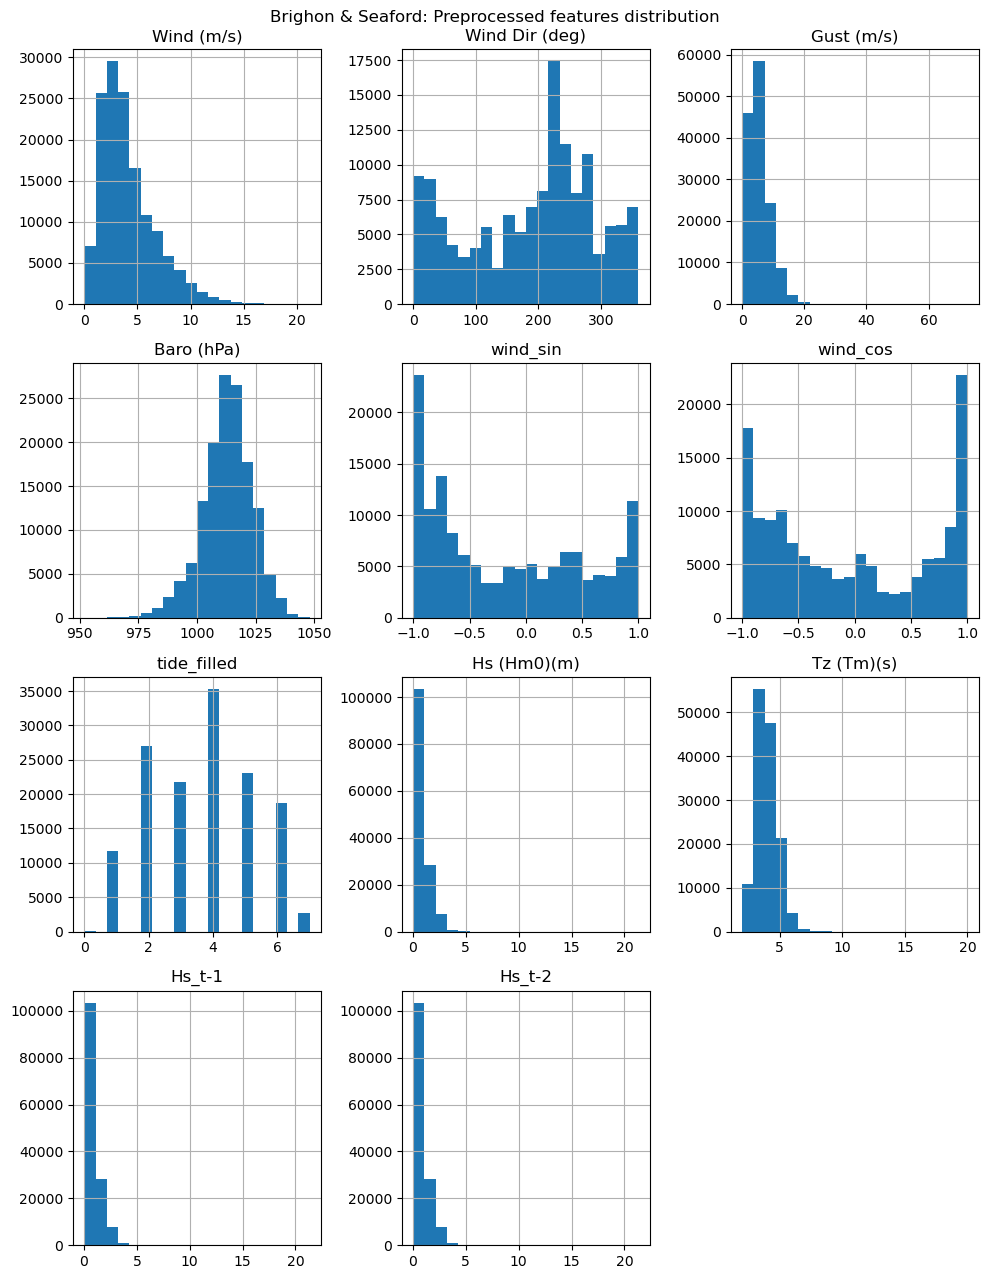

In [ ]:
#Composing numeric columns
cols_numeric = dataset_final.select_dtypes(include=['number']).columns
#Overview of data distribution with histogram
dataset_final[cols_numeric].hist(figsize=(10, 13), bins=20)

#Setting title
plt.suptitle('Brighon & Seaford: Preprocessed features distribution')

#Adjusting the padding
plt.tight_layout()

# Showing the chart
plt.show()

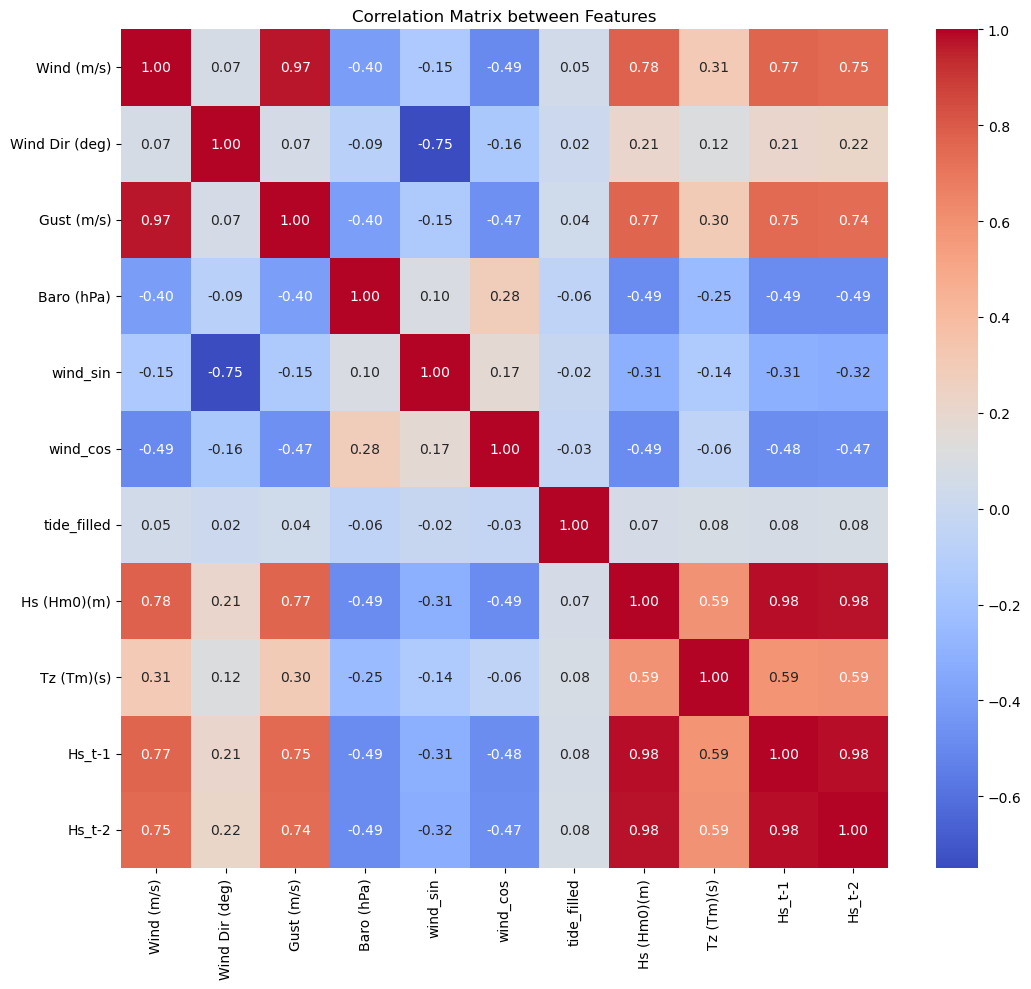

In [ ]:


#Overview of correlation between features with heatmap
plt.figure(figsize=(11, 10))

sns.heatmap(dataset_final[cols_numeric].corr(), cmap='coolwarm', annot=True, fmt='.2f')

#Setting title
plt.title('Correlation Matrix between Features')

#Adjusting the padding
plt.tight_layout()

#Showing the chart
plt.show()

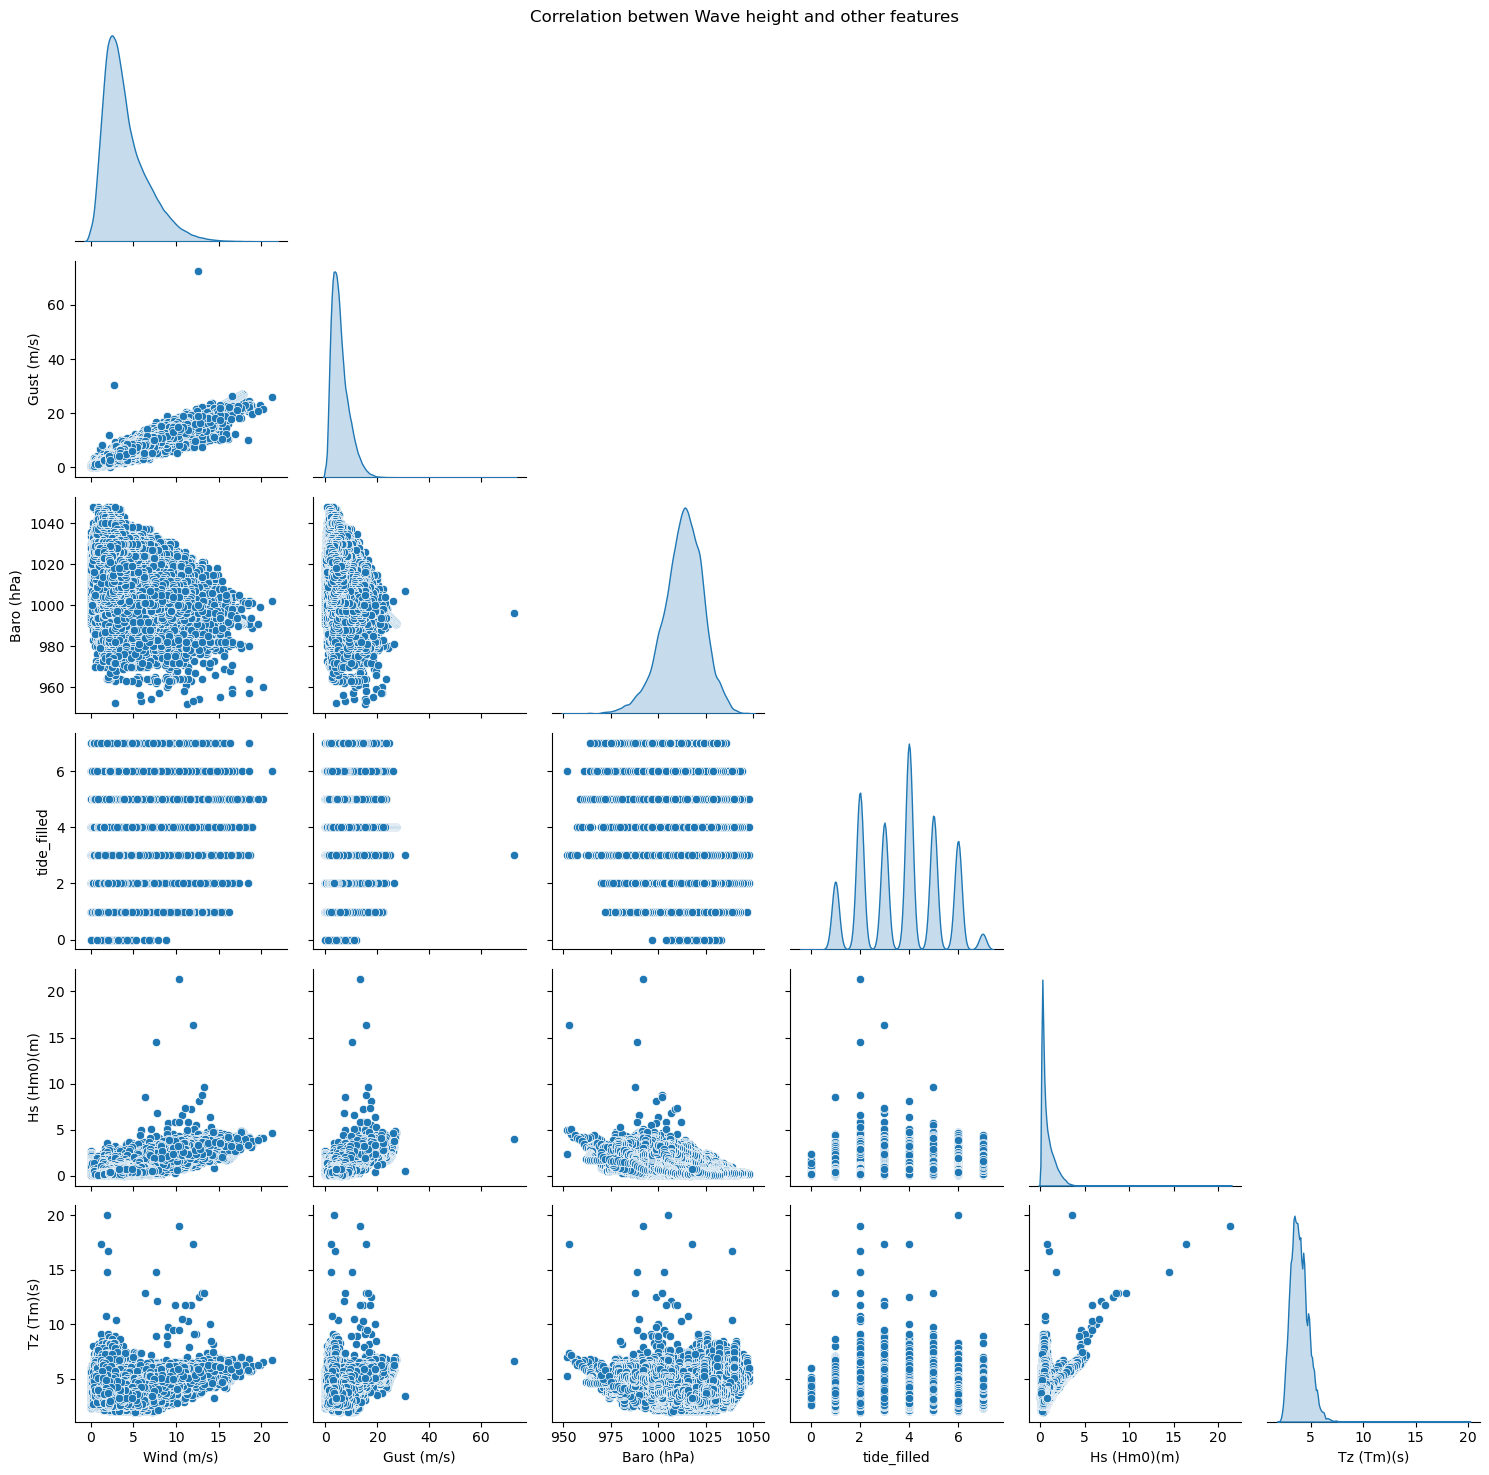

In [ ]:
#Overview of the correlation between Hs (Hm0)(m) and some features with pairplot

#Setting target features
'''
Target Feature List:
Wind (m/s), Wind Dir (deg), Gust (m/s), Baro (hPa), wind_sin, wind_cos,
tide_filled, Hs (Hm0)(m),	Tz (Tm)(s),	Hs_t-1,	Hs_t-2
'''
#For all numeric features
#cols_targets = cols_numeric
cols_targets = ['Wind (m/s)', 'Gust (m/s)', 'Baro (hPa)', 'tide_filled', 'Hs (Hm0)(m)','Tz (Tm)(s)']

sns.pairplot(dataset_final[cols_targets], diag_kind='kde', corner=True)


plt.suptitle('Correlation betwen Wave height and other features')


plt.tight_layout()


plt.show()

In [ ]:
cols_targets

['Wind (m/s)',
 'Gust (m/s)',
 'Baro (hPa)',
 'tide_filled',
 'Hs (Hm0)(m)',
 'Tz (Tm)(s)']

Variance Inflation Factor (VIF)
    Feature  Intercept       VIF
 Gust (m/s)          1 65.044203
 Wind (m/s)          1 61.319407
 Baro (hPa)          1 26.438216
 Tz (Tm)(s)          1 25.177642
tide_filled          1  6.592271


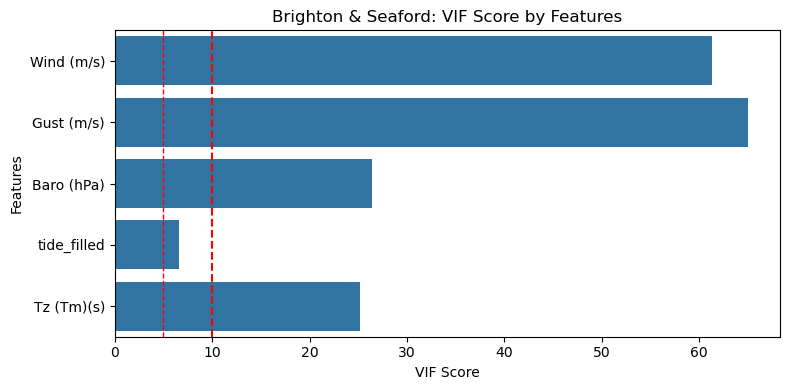

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Creating a dataset with features
df_exog = dataset_final[cols_targets].copy()

#Removing the target column
df_exog = df_exog.drop('Hs (Hm0)(m)', axis=1)
df_exog = df_exog.astype(float).dropna()

#Checking the multicollinearity using Variance Inflation Factor (VIF)
df_vif = pd.DataFrame()

df_vif['Feature'] = df_exog.columns
df_vif['Intercept'] = 1
df_vif['VIF'] = [variance_inflation_factor(df_exog.values, i) for i in range(len(df_exog.columns))]

print('Variance Inflation Factor (VIF)')
print(df_vif.sort_values(by='VIF', ascending=False).to_string(index=False))

#Visualization
plt.figure(figsize=(8, 4))

sns.barplot(data=df_vif, x='VIF', y='Feature')

#Adding the guide lines
plt.axvline(x=5, color='r', linestyle='--', linewidth=1)
plt.axvline(x=10, color='r', linestyle='--', linewidth=1.5)

plt.title('Brighton & Seaford: VIF Score by Features')
plt.xlabel('VIF Score')
plt.ylabel('Features')


plt.tight_layout()


plt.show()

In [ ]:
df_tmp = dataset_final.copy()

In [ ]:
print(dataset_final.columns.tolist())

['Wind (m/s)', 'Wind Dir (deg)', 'Gust (m/s)', 'Baro (hPa)', 'wind_sin', 'wind_cos', 'tide_filled', 'Hs (Hm0)(m)', 'Tz (Tm)(s)', 'Hs_t-1', 'Hs_t-2']


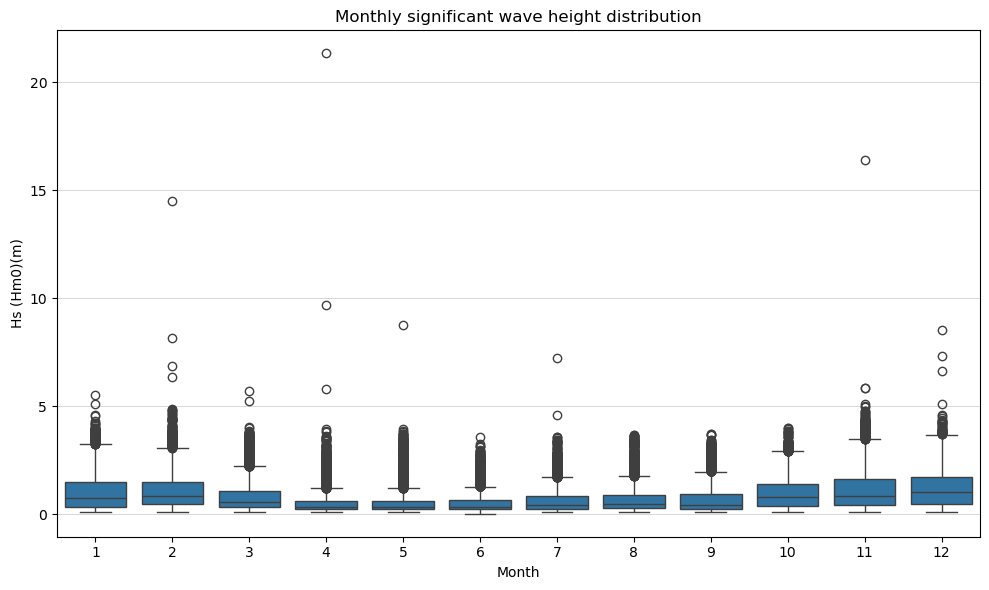

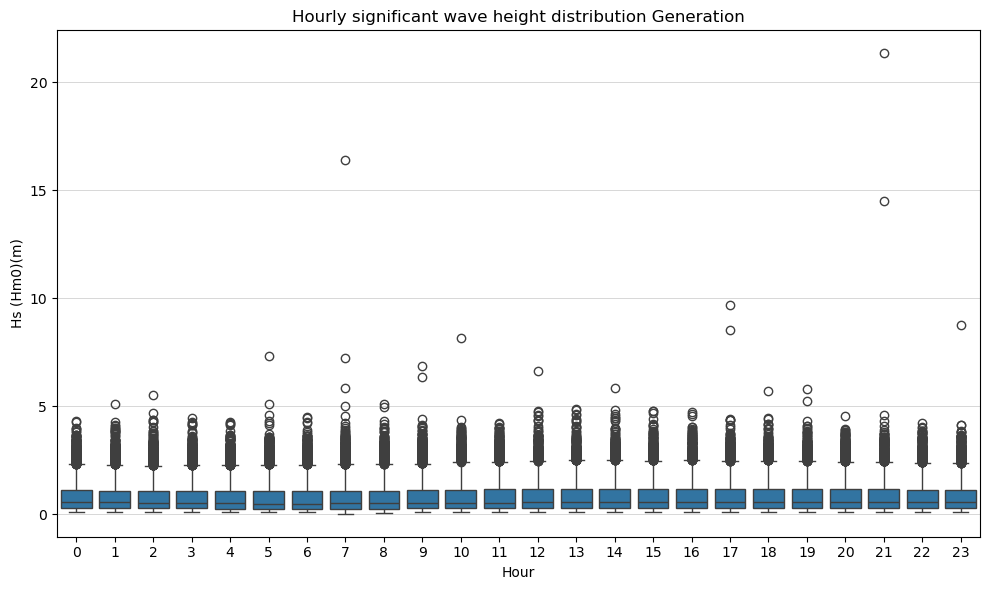

In [ ]:
#Append the columns month and hour
df_tmp['month'] = df_tmp.index.month
df_tmp['hour'] = df_tmp.index.hour

#Defineinga transient function for boxplot
def transient_boxplot(data, x, title, xlabel):
  # Set figure size
  plt.figure(figsize=(10, 6))

  sns.boxplot(data=data, x=x, y='Hs (Hm0)(m)')


  plt.title(title)
  plt.xlabel(xlabel)
  plt.ylabel('Hs (Hm0)(m)')
  plt.grid(axis='y', alpha=0.7, linestyle='-', linewidth=0.5)

  plt.tight_layout()

  plt.show()

  return

#Overview of monthly wave height distribution
transient_boxplot(df_tmp, 'month', 'Monthly significant wave height distribution', 'Month')

#Overview of hourly wave height distribution
transient_boxplot(df_tmp, 'hour', 'Hourly significant wave height distribution Generation', 'Hour')

In [ ]:
#Defining a transient function for screening the outliers
def screen_outliers_by_iqr(data, column, extreme=False, inclusive=True):
  #Calculate the quartiles and the interquartile range
  q1 = data[column].quantile(0.25)
  q3 = data[column].quantile(0.75)

  iqr = q3 - q1

  #Determine the coefficient
  coef = 3 if extreme else 1.5

  #Setting the lower and upper bounds
  lbound = q1 - coef * iqr
  ubound = q3 + coef * iqr

  #Return the filtered dataset
  if (inclusive):
    rt = data[(data[column] >= lbound) & (data[column] <= ubound)]
  else:
    rt = data[(data[column] > lbound) & (data[column] < ubound)]

  return rt

#Detect outliers by IQR based on generation_mw with mild and inclusive options
df_clean_iqr = screen_outliers_by_iqr(df_tmp, 'Hs (Hm0)(m)', extreme = True)

#Detect outliers based on domain knowledge
#If wind is extreme but waves areow, it may be due to sensor failure or missing data.
#Setting the thresholds: thresh_wind_calm <  1, thresh_wind_extreme > 4
thresh_wind_calm = 1
thresh_wind_extreme = 4

df_clean_dk = df_clean_iqr[~((df_clean_iqr['Wind (m/s)'] < thresh_wind_calm) & (df_clean_iqr['Hs (Hm0)(m)'] > thresh_wind_extreme))]

df_clean_final = df_clean_dk[df_clean_dk['Hs (Hm0)(m)']<=7]

In [ ]:
print(f"Original rows: {df_clean_dk.shape[0]}")
print(f"Rows remaining after outlier filtering: {df_clean_dk.shape[0]}")

Original rows: 139940
Rows remaining after outlier filtering: 139940


In [ ]:
#Setting the final dataset
df_curated = df_clean_dk

In [ ]:
#print(X_train.isna().sum())

Performance Evaluation Metrics for Linear Regression Model
R²Score: 0.3061
MAE:      0.4045 metres
MSE:      0.3218
RMSE:     0.5673 metres

Estimated Coefficients
      Feature  Coefficient
      Hs_t-48     0.404627
    Wind_t-48     0.046908
  tide_filled     0.025698
wind_sin_t-48    -0.013565
    Baro_t-48    -0.051360
    Gust_t-48    -0.055638
      Hs_t-49    -0.061038
wind_cos_t-48    -0.093530


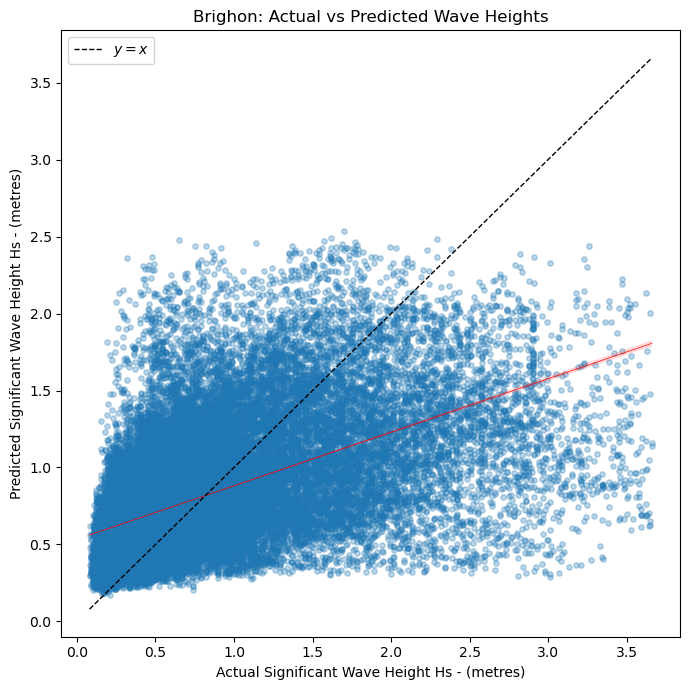

In [ ]:
#Creating a 24 hour step to predict
shift_steps = 48
#Lagging all real-time observed variables by 24 hours
df_curated['Wind_t-48'] = df_curated['Wind (m/s)'].shift(shift_steps)
df_curated['Gust_t-48'] = df_curated['Gust (m/s)'].shift(shift_steps)
df_curated['Baro_t-48'] = df_curated['Baro (hPa)'].shift(shift_steps)
df_curated['wind_sin_t-48'] = df_curated['wind_sin'].shift(shift_steps)
df_curated['wind_cos_t-48'] = df_curated['wind_cos'].shift(shift_steps)

#Allining my wave height lags to be 24 hours (and older)
df_curated['Hs_t-48'] = df_curated['Hs (Hm0)(m)'].shift(shift_steps)
df_curated['Hs_t-49'] = df_curated['Hs (Hm0)(m)'].shift(shift_steps + 1) # 24.5 hours ago

#Setting the features to be used in the model
#All of the numeric features except for the target 'Hs (Hm0)(m)
#features = df_curated.select_dtypes(include=['number']).columns.drop('generation_mw').to_list()
features = [    'Wind_t-48', 'Gust_t-48', 'Baro_t-48',
    'wind_sin_t-48', 'wind_cos_t-48',
    'tide_filled', 'Hs_t-48', 'Hs_t-49']

#Dropping row with Nan value/s
df_model = df_curated[features + ['Hs (Hm0)(m)']].dropna()

#Setting variables
X = df_model[features]
y = df_model['Hs (Hm0)(m)']

#Split the dataset with the test size of 30%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False, random_state=random_seed
)

scaler = StandardScaler()

#Learn and scale based only on the past training data parameters
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Converting back to clean tracking DataFrames
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

#Fit
reg = LinearRegression().fit(X_train_final, y_train)

#Test
y_pred = reg.predict(X_test_final)

#The performance evaluation metrics
print('Performance Evaluation Metrics for Linear Regression Model')
print(f'R²Score: {r2_score(y_test, y_pred):.4f}')
print(f'MAE:      {mean_absolute_error(y_test, y_pred):.4f} metres')
print(f'MSE:      {mean_squared_error(y_test, y_pred):.4f}')
print(f'RMSE:     {root_mean_squared_error(y_test, y_pred):.4f} metres')

#Feature Importance based on estimated coefficients
print('\nEstimated Coefficients')
print(pd.DataFrame({'Feature': features, 'Coefficient': reg.coef_}).sort_values(by='Coefficient', ascending=False).to_string(index=False))

#Visualization of actual and predicted values
plt.figure(figsize=(7, 7))

sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3, 's':15}, line_kws={'color':'red', 'linewidth':0.5})

#Adding the baseline as a prediction for reference
pt_max = max(y_test.max(), y_pred.max())
pt_min = min(y_test.min(), y_pred.min())

plt.plot([pt_min, pt_max], [pt_min, pt_max], color='black', label=r'$y = x$', linestyle='--', linewidth=1)


plt.title('Brighon: Actual vs Predicted Wave Heights')
plt.xlabel('Actual Significant Wave Height Hs - (metres)')
plt.ylabel('Predicted Significant Wave Height Hs - (metres)')

plt.legend()

plt.tight_layout()

plt.show()

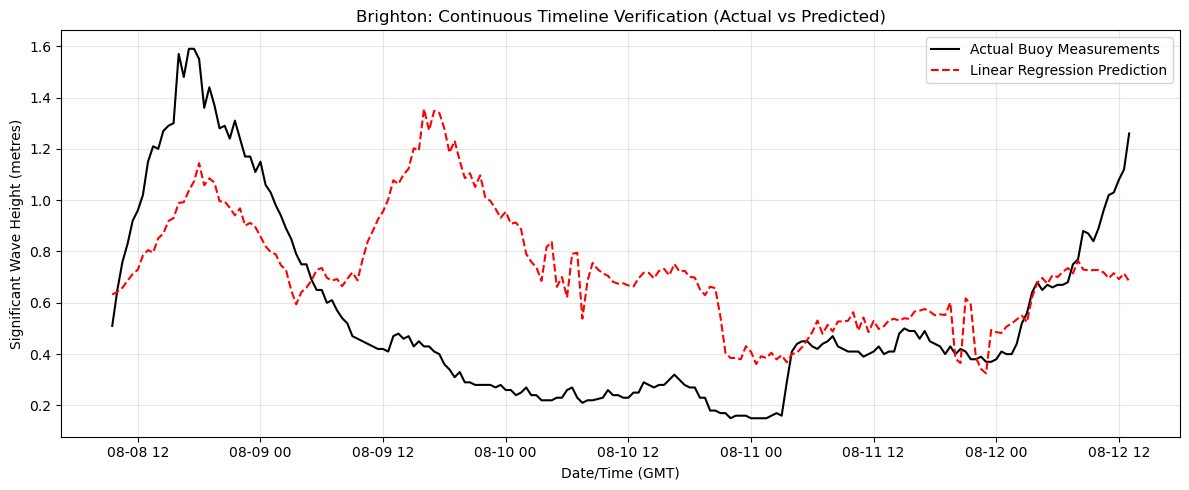

In [ ]:
plt.figure(figsize=(12, 5))

#Plot a slice of the first 200 rows
plt.plot(y_test.index[:200], y_test.values[:200], label='Actual Buoy Measurements', color='black', linewidth=1.5)
plt.plot(y_test.index[:200], y_pred[:200], label='Linear Regression Prediction', color='red', linestyle='--', linewidth=1.5)

plt.title('Brighton: Continuous Timeline Verification (Actual vs Predicted)')
plt.ylabel('Significant Wave Height (metres)')
plt.xlabel('Date/Time (GMT)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Long Term Short Term Memory - Time Series Model

In [ ]:
df_curated_LSTM = df_curated.copy()
df_curated_LSTM.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 139940 entries, 2018-01-01 02:00:00 to 2026-01-01 00:00:00
Data columns (total 20 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Wind (m/s)      139940 non-null  float64
 1   Wind Dir (deg)  139940 non-null  float64
 2   Gust (m/s)      139940 non-null  float64
 3   Baro (hPa)      139940 non-null  float64
 4   wind_sin        139940 non-null  float64
 5   wind_cos        139940 non-null  float64
 6   tide_filled     139940 non-null  Int64  
 7   Hs (Hm0)(m)     139940 non-null  float64
 8   Tz (Tm)(s)      139940 non-null  float64
 9   Hs_t-1          139940 non-null  float64
 10  Hs_t-2          139940 non-null  float64
 11  month           139940 non-null  int32  
 12  hour            139940 non-null  int32  
 13  Wind_t-48       139892 non-null  float64
 14  Gust_t-48       139892 non-null  float64
 15  Baro_t-48       139892 non-null  float64
 16  wind_sin_t-48   139892

In [ ]:
features = ['Wind (m/s)', 'Gust (m/s)','tide_filled','Tz (Tm)(s)','Baro (hPa)', 'wind_sin','wind_cos','Hs_t-1',	'Hs_t-2']

target = 'Hs (Hm0)(m)'

df_dropped_data = df_curated_LSTM.iloc[-50000:].reset_index(drop=True)

wave_dataset = df_dropped_data[features+[target]]

In [ ]:
wave_dataset

,Wind (m/s),Gust (m/s),tide_filled,Tz (Tm)(s),Baro (hPa),wind_sin,wind_cos,Hs_t-1,Hs_t-2,Hs (Hm0)(m)
0,0.6,0.9,1,3.7,1014.0,0.754710,0.656059,0.15,0.16,0.15
1,1.1,1.6,1,3.6,1014.0,0.913545,0.406737,0.15,0.15,0.14
2,1.5,2.3,1,3.7,1013.0,0.990268,0.139173,0.14,0.15,0.15
3,2.3,3.5,1,3.6,1013.0,0.978148,-0.207912,0.15,0.14,0.15
4,1.4,1.7,1,3.4,1013.0,0.961262,0.275637,0.15,0.15,0.22
...,...,...,...,...,...,...,...,...,...,...
49995,3.8,4.3,5,3.1,1020.0,-0.994522,0.104528,0.43,0.37,0.65
49996,3.9,4.4,5,3.2,1020.0,-0.990268,0.139173,0.65,0.43,0.71
49997,4.2,4.9,4,3.3,1019.0,-0.994522,0.104528,0.71,0.65,0.74
49998,4.9,6.0,4,3.3,1019.0,-0.996195,0.087156,0.74,0.71,0.74


In [ ]:
future_steps = 48
seq_length = 96
#Transforming the time series sequence with MinMaxScaler
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

x_scaled = scaler_x.fit_transform(wave_dataset)
y_scaled = scaler_y.fit_transform(wave_dataset[[target]])

#Genreating the sequence
seq_x = []
seq_y = []

for i in tqdm(range(len(wave_dataset) - seq_length - future_steps + 1), desc='Generating sequence...'):
  seq_x.append(x_scaled[i : i + seq_length])
  seq_y.append(y_scaled[i + seq_length : i + seq_length + future_steps].flatten())


#Setting the features and the label
X = torch.FloatTensor(np.array(seq_x))
y = torch.FloatTensor(np.array(seq_y))

#Spliting the dataset
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

Generating sequence...: 100%|████████████████████████████████████████████████| 49857/49857 [00:00<00:00, 185144.23it/s]


In [ ]:
class LSTMWaveHeightBase(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, num_layers=1):
    super().__init__()

    #LSTM model
    self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    out, (hn,cn) = self.lstm(x)

    return self.fc(out[:, -1, :])


#Making the prediction model with hidden_size = 48
model = LSTMWaveHeightBase(input_size =10, hidden_size = 48, output_size=future_steps)

#Setting the optimizer with default learning rate 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


#Setting the dataloader with batch_size=64 and shuffle=True
loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)

criterion = nn.MSELoss()

#Setting the epochs
epochs = 10

#Creating a progress bar with the epochs count
pbar = tqdm(range(epochs), desc='Training...')

costs = []

for epoch in pbar:
  model.train()

  cost = 0

  #Calculate the errors
  for batch_x, batch_y in loader:
    #Initialize the gradient
    optimizer.zero_grad()

    y_pred = model(batch_x)

    loss = criterion(y_pred, batch_y)

    #Calculating the gradient of each weight in the model on the result based on the calculated loss
    loss.backward()

    #Update the weights
    optimizer.step()

    #Add the loss of the current batch to the cost, meaning the total epoch loss
    cost += loss.item()

  #Calculate the average cost
  cost_average = cost / len(loader)

  pbar.set_postfix({'Loss': f'{cost_average:.6f}'})


#Switch to evaluation mode
model.eval()

#Predict and inverse transform
with torch.no_grad():
  kw_pred = scaler_y.inverse_transform(model(X_test).detach().numpy()).flatten()
  kw_actual = scaler_y.inverse_transform(y_test.detach().numpy()).flatten()

Training...: 100%|██████████████████████████████████████████████████████| 10/10 [01:26<00:00,  8.63s/it, Loss=0.012619]


In [ ]:

#Calculate the errors
errors = kw_actual - kw_pred

#Compose the dataframe for results
df_results = pd.DataFrame({'Actual': kw_actual.flatten(), 'Predicted': kw_pred.flatten(), 'Error': errors.flatten()})

#Calculate the metrics
r2 = r2_score(kw_actual, kw_pred)
rmse = np.sqrt(mean_squared_error(kw_actual, kw_pred))
mae = mean_absolute_error(kw_actual, kw_pred)

# Calculate only the range where the actual value is 1.0 or greater for MAPE
mask = kw_actual > 1.0
mape = np.mean(np.abs((kw_actual[mask] - kw_pred[mask]) / kw_actual[mask])) * 100 if (np.any(mask)) else 0

print(f'Prediction Report')
print(f'R² Score: {r2:.4f}')
print(f'MAPE: {mape:.2f}%')
print(f'RMSE: {rmse:.4f} kW')
print(f'MAE: {mae:.4f} kW')

Prediction Report
R² Score: 0.6549
MAPE: 24.17%
RMSE: 0.4014 kW
MAE: 0.2624 kW


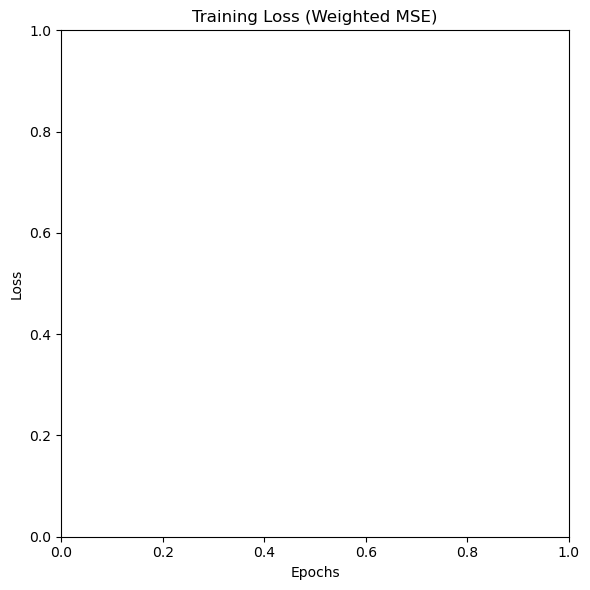

In [ ]:
plt.figure(figsize=(6, 6))

sns.lineplot(data=costs, color='orange', linewidth=2)

plt.title('Training Loss (Weighted MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

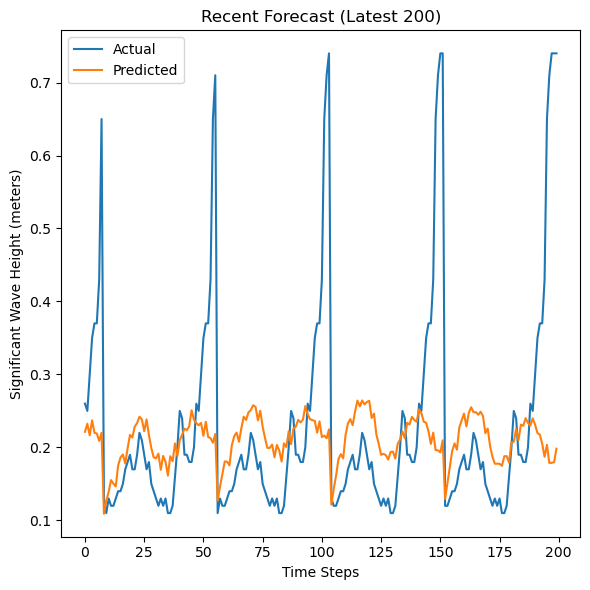

In [ ]:
plt.figure(figsize=(6, 6))

#Setting the time steps
time_steps = 200

sns.lineplot(data=kw_actual[-time_steps:], label='Actual')
sns.lineplot(data=kw_pred[-time_steps:], label='Predicted')


plt.title(f'Recent Forecast (Latest {time_steps})')
plt.xlabel('Time Steps')
plt.ylabel('Significant Wave Height (meters)')


plt.tight_layout()


plt.show()

### Optimised LSTM

In [ ]:
#!pip install optuna
import optuna

In [ ]:
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import optuna
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {device}")

class LSTMWaveHeightLearning(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, num_layers=5):
    super().__init__()
    self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
    self.fc = nn.Sequential(nn.Linear(hidden_size, hidden_size // 2), nn.ReLU(), nn.Linear(hidden_size // 2, output_size))

  def forward(self, x):
    out, _ = self.lstm(x)
    return self.fc(out[:, -1, :])

def objective(trial):
    hidden_size = trial.suggest_int('hidden_size', 16, 128)
    learning_rate = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    optuna_train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=1024, shuffle=True)
    optuna_val_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=1024, shuffle=False)

    input_size_train = X_train.shape[2]
    output_size_train = future_steps

    model = LSTMWaveHeightLearning(input_size=input_size_train, hidden_size=hidden_size, output_size=output_size_train).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    model.train()
    for epoch in range(20):
        batch_bar = tqdm(optuna_train_loader, desc=f"Trial {trial.number} | Epoch {epoch+1}/20", leave=False)
        for (data, target) in batch_bar:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            y_pred = model(data)
            weight = 1.0 + torch.exp(-target * 5.0)
            batch_loss = torch.mean(weight * (y_pred - target)**2)
            batch_loss.backward()
            optimizer.step()

            #Show the current loss value instantly
            batch_bar.set_postfix(loss=f"{batch_loss.item():.4f}")

    val_loss_sum = 0.0
    model.eval()
    with torch.no_grad():
        for (data, target) in optuna_val_loader:
            data, target = data.to(device), target.to(device)
            y_pred = model(data)
            weight = 1.0 + torch.exp(-target * 5.0)
            val_batch_loss = torch.mean(weight * (y_pred - target)**2)
            val_loss_sum += val_batch_loss.item()

    return val_loss_sum / len(optuna_val_loader)

study = optuna.create_study(direction='minimize')

start_time = time.time()
study.optimize(objective, n_trials=1)
end_time = time.time()

trial_duration = end_time - start_time
print(f"\n[INFO] One trial took: {trial_duration:.2f} seconds")


[I 2026-05-27 11:26:47,656] A new study created in memory with name: no-name-23e6fe40-8b25-43ed-a382-89ec2f897531


[INFO] Using device: cuda


Trial 0 | Epoch 1/20:   0%|          | 0/39 [00:00<?, ?it/s]

Trial 0 | Epoch 2/20:   0%|          | 0/39 [00:00<?, ?it/s]

Trial 0 | Epoch 3/20:   0%|          | 0/39 [00:00<?, ?it/s]

...

Trial 0 | Epoch 18/20:   0%|          | 0/39 [00:00<?, ?it/s]

Trial 0 | Epoch 19/20:   0%|          | 0/39 [00:00<?, ?it/s]

Trial 0 | Epoch 20/20:   0%|          | 0/39 [00:00<?, ?it/s]

[I 2026-05-27 11:28:18,850] Trial 0 finished with value: 0.01618830687366426 and parameters: {'hidden_size': 83, 'lr': 0.0020770429448032507}. Best is trial 0 with value: 0.01618830687366426.



[INFO] One trial took: 91.19 seconds


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {device}")
class LSTMWaveHeightOptimised(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, num_layers=4):
    super().__init__()
    self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)

    #Fully connected layer
    self.fc = nn.Sequential(nn.Linear(hidden_size, hidden_size // 2), nn.ReLU(), nn.Linear(hidden_size // 2, output_size))

  def forward(self, x):
    out, _ = self.lstm(x)

    return self.fc(out[:, -1, :])

class EarlyStopping:
  def __init__(self, max_patience=15, delta=0, path='best_model.pth'):
    self.max_patience = max_patience
    self.delta = delta
    self.path = path
    self.patience = 0
    self.best_loss = float('inf')
    self.stop = False

  def __call__(self, loss, model):
    if (loss < (self.best_loss - self.delta)):
      self.best_loss = loss
      self.patience = 0

      torch.save(model.state_dict(), self.path)
    else:
      self.patience += 1

      if (self.patience >= self.max_patience):
        self.stop = True

input_size_3D = X_train.shape[2]

model = LSTMWaveHeightOptimised(input_size_3D, hidden_size = 505, output_size=future_steps).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.002421439245895593)

loader = DataLoader(TensorDataset(X_train, y_train), batch_size=256, shuffle=True)

max_patience = 15
delta = 0
path = 'best_model.pth'

early_stopping = EarlyStopping(max_patience=max_patience, delta=delta, path=path)

epochs = 10

pbar = tqdm(range(epochs), desc='Training...')

costs = []

for epoch in pbar:
  model.train()

  cost = 0

  for batch_x, batch_y in loader:
    batch_x = batch_x.to(device)
    batch_y = batch_y.to(device)
    optimizer.zero_grad()

    y_pred = model(batch_x)
    criterion = nn.MSELoss()
    loss = criterion(y_pred, batch_y)

    loss.backward()

    optimizer.step()

    cost += loss.item()

  cost_average = cost / len(loader)

  costs.append(cost_average)

  early_stopping(cost_average, model)

  pbar.set_postfix({'Loss': f'{cost_average:.6f}', 'Patience': f'{early_stopping.patience}/{early_stopping.max_patience}'})

  if (early_stopping.stop):
    print(f'\nTraining was stopped early at {epoch + 1}...')

    break

model.load_state_dict(torch.load(path, map_location=device, weights_only=True))

model.eval()

test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=256, shuffle=False)

kw_pred_optim_list = []
kw_actual_optim_list = []

#Predicting and inverse transform in batches
with torch.no_grad():
  for batch_x_test, batch_y_test in test_loader:
    batch_x_test = batch_x_test.to(device)
    batch_y_test = batch_y_test.to(device)

    y_pred_batch = model(batch_x_test)

    kw_pred_optim_list.append(scaler_y.inverse_transform(y_pred_batch.cpu().detach().numpy()))
    kw_actual_optim_list.append(scaler_y.inverse_transform(batch_y_test.cpu().detach().numpy()))

kw_pred_optim = np.concatenate(kw_pred_optim_list).flatten()
kw_actual_optim = np.concatenate(kw_actual_optim_list).flatten()

[INFO] Using device: cuda


Training...:   0%|          | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
errors_optim = kw_actual_optim - kw_pred_optim

df_results_optim = pd.DataFrame({'Actual': kw_actual_optim, 'Predicted': kw_pred_optim, 'Error': errors})

r2_op = r2_score(kw_actual_optim, kw_pred_optim)
rmse_op = np.sqrt(mean_squared_error(kw_actual_optim, kw_pred_optim))
mae_op = mean_absolute_error(kw_actual_optim, kw_pred_optim)

mask_op = kw_actual_optim > 1.0
mape_op = np.mean(np.abs((kw_actual_optim[mask_op] - kw_pred_optim[mask_op]) / kw_actual_optim[mask_op])) * 100 if (np.any(mask_op)) else 0


print(f'Prediction Report')
print(f'R² Score: {r2_op:.4f}')
print(f'MAPE: {mape_op:.2f}%')
print(f'RMSE: {rmse_op:.4f} kW')
print(f'MAE: {mae_op:.4f} kW')
print(f'Prediction Report compared to baseline')
print(f'R²: {r2:.4f} kW')
print(f'R² Optimised: {r2_op:.4f} kW')